# Build basic 2-Layer MLP to solve the xor-Problem

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs #for data generatio
from sklearn.model_selection import train_test_split #for test set generation
import torch
import torch.nn as nn


In [9]:
X, y = make_blobs(n_samples=200, n_features=2, cluster_std=.1
                  ,centers= [(1,1), (1,0), (0,0),(0,1)])

In [10]:
#make blobs into binary problem
y[y==2]=0
y[y==3]=1

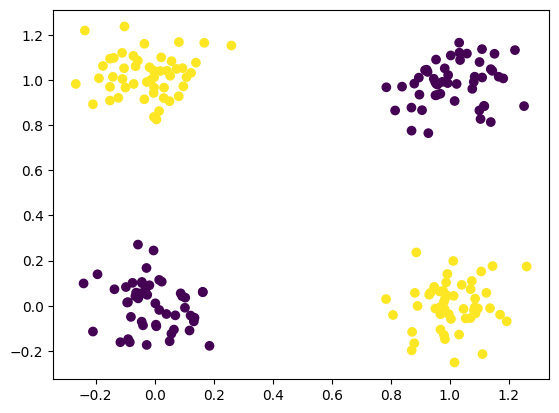

In [11]:
plt.scatter(X[:,0],X[:,1],c=y)

## Steps:
* build train and test sets
* write MLP class in Pytorch with two layers with adjustable number of perceptrons
* use nn.linear and nn.Sigmoid() units
* train your model
* test your model

Prepare Training and Test Data


In [45]:
#split in train and test
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

#np->torch
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

In [46]:
#have look
y_train

tensor([0., 1., 1., 1., 1., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0., 1., 0.,
        1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0.,
        0., 0., 0., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 0.,
        1., 1., 1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 1., 1., 0., 0., 0., 1.,
        1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 1., 1., 1.,
        1., 1., 0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0., 1., 0., 1., 1., 1.,
        0., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
        0., 1., 1., 0., 0., 1., 0., 0.])

Build Perceptrons

In [47]:
# Fine Declaration - Maybe nice to make
class MLP2Simple(torch.nn.Module):
    def __init__(self, hiddensize_1, hiddensize_2):
        super().__init__()
        self.fc1 = torch.nn.Linear(2,hiddensize_1)
        self.sigmoid1 = torch.nn.Sigmoid()

        self.fc2 = torch.nn.Linear(hiddensize_1,hiddensize_2)
        self.sigmoid2 = torch.nn.Sigmoid()

        self.fc3 = torch.nn.Linear(hiddensize_2,1)




    def forward(self, x):
        # Durch die Schichten propagieren
        x = self.sigmoid1(self.fc1(x))
        x = self.sigmoid2(self.fc2(x))
        x = self.fc3(x)  # Ausgangsschicht
        return x



Get Instance of Model

In [54]:
#get instance of perceptron model
model = MLP2Simple(1,2)

#define loss function
criterion = torch.nn.CrossEntropyLoss()

#define optimizer -> SGD with learning rate lr
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)


In [55]:
#run test data theogh untrained model
model.eval() #set to eval mode
model(x_test)

tensor([[-0.4473],
        [-0.4463],
        [-0.4240],
        [-0.4456],
        [-0.4485],
        [-0.4456],
        [-0.4272],
        [-0.4262],
        [-0.4306],
        [-0.4272],
        [-0.4401],
        [-0.4402],
        [-0.4298],
        [-0.4257],
        [-0.4254],
        [-0.4248],
        [-0.4459],
        [-0.4412],
        [-0.4409],
        [-0.4454],
        [-0.4247],
        [-0.4298],
        [-0.4403],
        [-0.4248],
        [-0.4246],
        [-0.4377],
        [-0.4260],
        [-0.4473],
        [-0.4272],
        [-0.4406],
        [-0.4425],
        [-0.4236],
        [-0.4271],
        [-0.4270],
        [-0.4253],
        [-0.4464],
        [-0.4411],
        [-0.4253],
        [-0.4227],
        [-0.4271],
        [-0.4236],
        [-0.4303],
        [-0.4463],
        [-0.4239],
        [-0.4329],
        [-0.4257],
        [-0.4404],
        [-0.4357],
        [-0.4448],
        [-0.4393],
        [-0.4331],
        [-0.4242],
        [-0.

In [56]:
model.train() #set to train mode
epoch = 50
for epoch in range(epoch):
    optimizer.zero_grad()
    # Forward pass
    y_pred = model(x_train)
    # Compute Loss
    loss = criterion(y_pred.squeeze(), y_train)

    print('Epoch {}: train loss: {}'.format(epoch, loss.item()))
    # Backward pass
    loss.backward()
    #make gradient update
    optimizer.step()

Epoch 0: train loss: 367.31475830078125
Epoch 1: train loss: 367.3146667480469
Epoch 2: train loss: 367.31451416015625
Epoch 3: train loss: 367.31439208984375
Epoch 4: train loss: 367.3143310546875
Epoch 5: train loss: 367.314208984375
Epoch 6: train loss: 367.3140869140625
Epoch 7: train loss: 367.31402587890625
Epoch 8: train loss: 367.3138732910156
Epoch 9: train loss: 367.3138427734375
Epoch 10: train loss: 367.313720703125
Epoch 11: train loss: 367.3135681152344
Epoch 12: train loss: 367.3134460449219
Epoch 13: train loss: 367.3133544921875
Epoch 14: train loss: 367.3132629394531
Epoch 15: train loss: 367.31317138671875
Epoch 16: train loss: 367.31304931640625
Epoch 17: train loss: 367.3129577636719
Epoch 18: train loss: 367.31280517578125
Epoch 19: train loss: 367.31268310546875
Epoch 20: train loss: 367.3125915527344
Epoch 21: train loss: 367.3124694824219
Epoch 22: train loss: 367.3124084472656
Epoch 23: train loss: 367.312255859375
Epoch 24: train loss: 367.3121643066406
Epoch

Evaluate

In [57]:
model.eval() #set model to eval mode

#train
y_pred = model(x_train) #predict
y_pred=(y_pred>0.5).int().flatten() #argmax class lable
train_acc =torch.sum(y_pred == y_train.int())/ y_train.shape[0]
print("train ACC: ",train_acc.float())

train ACC:  tensor(0.4403)


In [58]:
#test
y_pred = model(x_test) #predict
y_pred=(y_pred>0.5).int().flatten() #argmax class lable
test_acc = torch.sum(y_pred == y_test.int()) / y_test.shape[0]
print("test ACC: ",test_acc.float())

test ACC:  tensor(0.6212)


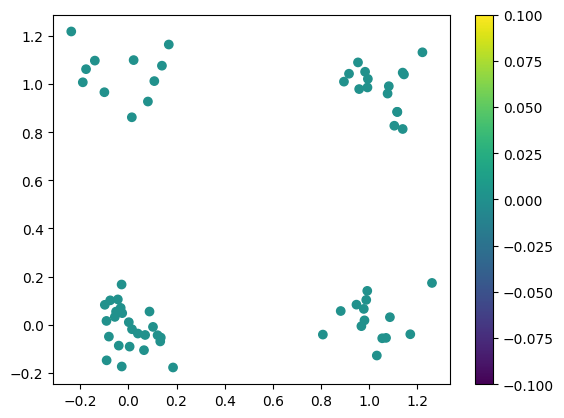

In [59]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_pred)
plt.colorbar()